In [50]:
using Pkg
Pkg.activate(".")

using LinearAlgebra, GenericLinearAlgebra, StaticArrays, SparseArrays, Random
using StatsBase
using Base.Threads
using CUDA, Adapt, KernelAbstractions, GPUArrays
using Plots, StatsPlots, JLD2
using Clustering, Graphs
using DictionaryLearning
using FLoops
using IterativeSolvers
using KrylovKit, Krylov

include("../debug.jl")

savepath = "../../temp/ssdl"

# plot theme
theme(:rose_pine)

# choose backend
back = CUDA.functional() ? CUDABackend() : CPU()

# set threads
BLAS.set_num_threads(nthreads())

println("$INF backend: $back")
println("$INF # threads: $(nthreads())")
;

  Activating 

[INF] backend: CUDABackend(false, false)
[INF] # threads: 32


project at `~/DictionaryLearning/examples/dictionary-learning`


In [44]:
@load "../../temp/fl-example/fls.jld2" fls
D = fls.G
normalize!.(eachcol(D))

m, k = size(D)
s = 1
n = 10000
t = 25

println("$INF m = $m")
println("$INF k = $k")
println("$INF n = $n")
println("$INF t = $t")
println("$INF s = $s")
println("$INF sizeof(Y) = $(m*n*sizeof(eltype(D))*1e-9)GB")
;

[INF] m = 775
[INF] k = 361
[INF] n = 10000
[INF] t = 25
[INF] s = 1
[INF] sizeof(Y) = 0.12400000000000001GB


In [45]:
D = adapt(back, D)
X_cpu = gen_sparse_samples(eltype(D), k, n, s)
X = adapt(back, X_cpu)
;

In [ ]:
println("$INF condition number of D: ", cond(D))
try
    println("$INF condition number of Y: $(cond(D*X))")
catch e
    if isa(e, OutOfGPUMemoryError) || isa(e, OutOfMemoryError)
        println("$WAR out of memory")
    else
        rethrow(e)
    end
end

In [ ]:
function get_white_2(
    Y::StridedMatrix{T}, k::Int, s::Int
) where T
    n = size(Y, 2)
    svdA = svd(Y)
    U, Σ = svdA.U, Diagonal(svdA.S)
    Σ *= sqrt(k/(n*s))
    W = U*Σ*U'
    Winv = U * inv(Σ) * U'

    return W, Winv
end

function get_white_2(D::StridedMatrix{T}) where T
    return get_white(D, size(D, 2), 1)
end

get_white_2 (generic function with 2 methods)

In [ ]:

W, Winv = get_white(D*X, k, s)
W_true, Winv_true = get_white(D)
D_white = Winv * D

println(norm(""))

;

[INF] cond(D): 1.0140364691501335e9


[INF] cond before whitening: 7.346926595690455e18
[INF] maximum covariance before whitening: 0.8419257837926731
[INF] cond after whitening: 9.729135602560166e18
[INF] maximum covariance after whitening: 0.82302962004063


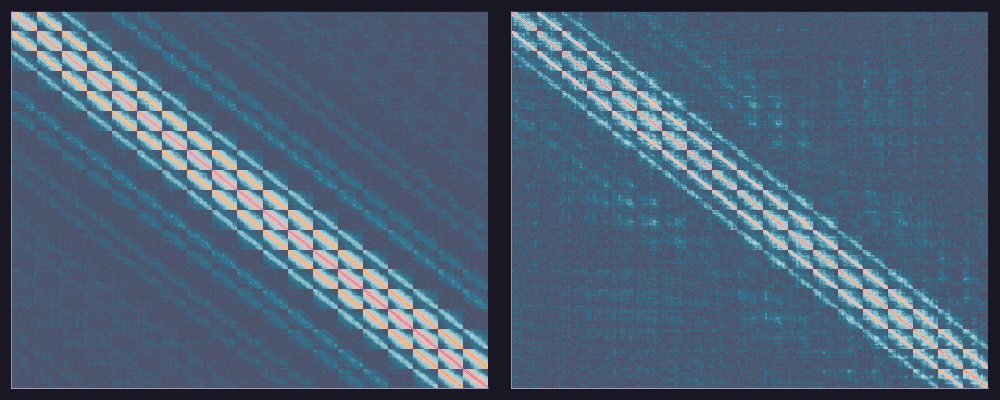

In [15]:
let
    # get available memory
    free_mem = get_free_mem(back)

    # choose how much workspace
    nwork = min(
        round(Int, 0.9 * get_free_mem(back) / sizeof(eltype(D))), 
        k*k
    )
    
    # create work space
    work = adapt(back, Vector{eltype(D)}(undef, nwork))

    mc = max_cov!(copy(D), work)
    mc_white = max_cov!(copy(D_white), work)

    println("$INF cond before whitening: $(cond(D*D'))")
    println("$INF maximum covariance before whitening: $mc")
    println("$INF cond after whitening: $(cond(D_white*D_white'))")
    println("$INF maximum covariance after whitening: $mc_white")
end

# force GPU cleanup
if back == CUDABackend()
    GC.gc()
    CUDA.reclaim()
end

p1 = heatmap(adapt(CPU(), abs.(D'*D)), yflip=true, legend=false, xticks=false, yticks=false)
savefig("$savepath/coh.pdf")

p2 = heatmap(adapt(CPU(), abs.(D_white'*D_white)), yflip=true, legend=false, xticks=false, yticks=false)
savefig("$savepath/coh-white.pdf")

plot(p1, p2, layout=(1,2), size=(1000, 400))

In [ ]:
# sfsrs = SSDLFakeSubRecStruct(D_white, X_cpu, s, t)
# sfsrs_true = SSDLFakeSubRecStruct(D_white, X_cpu, s, t)
# ssdl_subrec!(sfsrs)
# ssdl_subrec_true!(sfsrs_true)

# # force GPU cleanup
# if back == CUDABackend()
#     GC.gc()
#     CUDA.reclaim()
# end

# ;

In [7]:
# let
#     errs = subdist.(
#         eachslice(sfsrs.S, dims=3), 
#         eachslice(sfsrs_true.S, dims=3),
#         :opnorm
#     )
#     println("mean 2-norm error: $(mean(errs))")
#     p1 = dotplot(errs, label=:none, title="opnorm")

#     errs = subdist.(
#         eachslice(sfsrs.S, dims=3), 
#         eachslice(sfsrs_true.S, dims=3),
#         :fnorm
#     )
#     println("mean f-norm error: $(mean(errs))")
#     p2 = dotplot(errs, label=:none, title="fnorm")

#     return plot(p1, p2, layout=(1, 2), size=(1000, 400))
# end

In [154]:
ssds = SSDLSubDistStruct(sfsrs, :fnorm)
stsds = SSDLTrueSubDistStruct(sfsrs_true, :fnorm)
let
    ssdws = SSDLSubDistWorkStruct(ssds)
    sub_dist!(ssds, ssdws)
    sub_dist!(stsds, ssdws)
end

# force GPU cleanup
if back == CUDABackend()
    GC.gc()
    CUDA.reclaim()
end
;

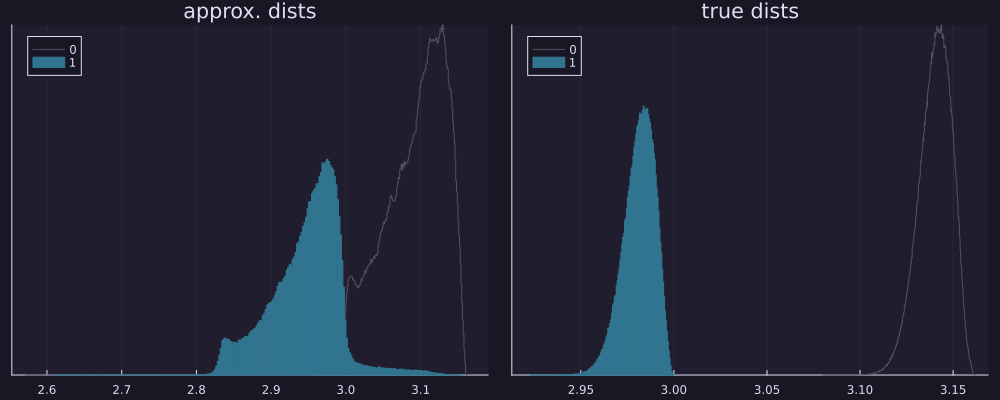

In [155]:
let 
    Cvec = vec(stsds.C)
    
    p1 = plot(title="approx. dists", yticks=:none)
    Dvec = copy(vec(adapt(CPU(), ssds.D)))
    for i in 0:1
        idxs = setdiff(findall(isequal(i), Cvec), 1:t+1:t^2)
        sds = Dvec[idxs]
        if length(sds) > 0
            histogram!(sds, linecolor = :match, label="$i")
        end
    end

    p2 = plot(title="true dists", yticks=:none)
    Dvec = vec(adapt(CPU(), stsds.D))
    for i in 0:1
        idxs = setdiff(findall(isequal(i), Cvec), 1:t+1:t^2)
        sds = Dvec[idxs]
        if length(sds) > 0
            histogram!(sds, linecolor = :match, label="$i")
        end
    end
    
    return plot(p1, p2, layout=(1, 2), size=(1000, 400))
end

In [156]:
function get_edge_graph!(g::AbstractGraph, ge::AbstractGraph)
    nedges = ne(g)
    edgelst = collect(edges(g))

    bufs = [Int[] for _ in 1:nedges]
    @floop ThreadedEx() for i in 1:nedges
        for j in (i+1):nedges
            if edgelst[i].src == edgelst[j].src || 
                edgelst[i].src == edgelst[j].dst || 
                edgelst[i].dst == edgelst[j].src || 
                edgelst[i].dst == edgelst[j].dst
                    push!(bufs[i], j)
            end
        end
    end

    for (i, bufi) in enumerate(bufs)
        for j in bufi
            add_edge!(ge, i, j)
        end
    end

    return ge
end

function ssdl_rec_dict!(
    Dr::StridedMatrix{T1},
    ssds::SSDLSubDistStruct{T1, T2},
    τ::Real
) where T1 where T2
    (; back, t, m, D, S) = ssds

    @assert T2 == real(T1)
    @assert get_backend(D) == ssds.back

    # move stuff to CPU
    D_cpu = Symmetric(Matrix{T2}(undef, t, t))
    copyto!(D_cpu.data, ssds.D.data)

    # build graph
    g = SimpleGraph(t)
    for i in 1:t
        for j in i+1:t
            sd = D_cpu[j, i]
            if sd < τ
                add_edge!(g, i, j)
            end
        end
    end
    
    # build edge graph
    eg = SimpleGraph(ne(g))
    get_edge_graph!(g, eg)

    println("$INF # nodes: $(nv(g))")
    println("$INF # edges: $(ne(g))")

    if ne(g) < k
        throw(ErrorException(
            "not enough edges to do spectral clustering;"* 
            "Try using more subspaces."
        ))
    end

    # cluster edge graph
    A = Float64.(adapt(back, adjacency_matrix(eg)))

    # symmetric normalized laplacian
    d = degree(eg)
    Disqt = adapt(back, Diagonal([x > 0 ? 1.0/sqrt(x) : 0.0 for x in d]))
    L = I - Disqt * (A * Disqt)

    println("$INF doing large eigsolve")
    elap = @elapsed begin
        x₀ = adapt(back, randn(ne(g))) # initial guess
        res = eigsolve(x -> L*x, x₀, k+10, :SR, krylovdim=2*k, issymmetric=true)
        U = hcat(res[2][2:k+1]...)
    end
    println("$TAB$INF elap: $elap")

    # normalize rows
    U ./= sqrt.(sum(abs2, U, dims=2))
    U_cpu = adapt(CPU(), U)

    # do clustering
    println("$INF doing kmeans")
    elap = @elapsed begin
        km = kmeans(U_cpu', k)
        agnmts = assignments(km)
    end
    println("$TAB$INF elap: $elap")

    # map edges back to nodes
    clstcounts = [zeros(Int, k) for _ in 1:t]
    for (i, ei) in enumerate(edges(g))
        u, v = src(ei), dst(ei)
        cid = agnmts[i]
        clstcounts[u][cid] += 1
        clstcounts[v][cid] += 1
    end
    
    # create vector indexing members of each simplex
    simps = [Int[] for _ in 1:k]

    # get which subspace are in each simplex
    for i in 1:t
        supi = partialsortperm(clstcounts[i], 1:s, rev=true)
        for j in supi
            push!(simps[j], i)
        end
    end

    println(mean(length.(simps)))

    # recover each column of dictionary
    M = adapt(back, Matrix{T1}(undef, m, m))
    for i in 1:k
        fill!(M, 0.0)
        for j in simps[i]
            M .+= view(S, :, :, j)*view(S, :, :, j)'
        end

        eig = eigen(Hermitian(M))
        eigvindx = sortperm(adapt(CPU(), eig.values), by=λ->-λ)
        view(Dr, :, i) .= view(eig.vectors, :, eigvindx[1])
    end
end

Dr_white = similar(D)
ssdl_rec_dict!(Dr_white, ssds, 3.05)

[INF] # nodes: 2000
[INF] # edges: 754319


CUDA.OutOfGPUMemoryError: Out of GPU memory trying to allocate 9.784 GiB
Effective GPU memory usage: 99.92% (23.624 GiB/23.643 GiB)
Memory pool usage: 19.872 GiB (22.656 GiB reserved)


In [ ]:
# align to true dictionary
let
    A = copy(D_white)
    B = copy(Dr_white)9
    normalize!.(eachcol(A))
    normalize!.(eachcol(B))
    align_dict!(A, B)
    println("$INF recovery error: $(norm(A - B)/norm(A))")
end

[INF] recovery error: 1.3262320489982704


In [158]:
# align to true dictionary
let
    A = copy(D)
    B = W*Dr_white
    normalize!.(eachcol(A))
    normalize!.(eachcol(B))
    align_dict!(A, B)
    println("$INF recovery error: $(norm(A - B)/norm(A))")
end

[INF] recovery error: 1.0922464354230228
